# This notebook shows how to apply the spin operators Sx, Sy, Sz to wavefunctions
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The spin operator
Elk's second-variational scheme reuses the SAME first-variational spatial orbitals for both spin channels, so the spin-up/spin-down blocks of `evecsv` alone determine the spin operator -- no muffin-tin integral needed, unlike the atom-projection operator:
$$ (S_z)_{mn}=\tfrac12(u_m^\dagger u_n - d_m^\dagger d_n), \quad (S_x)_{mn}=\tfrac12(u_m^\dagger d_n + d_m^\dagger u_n), \quad (S_y)_{mn}=\tfrac i2(d_m^\dagger u_n - u_m^\dagger d_n) $$
with $u_n,d_n$ the up/down row blocks of `evecsv`'s $n$-th column. $S_x,S_y,S_z$ are Hermitian, eigenvalues $\pm\tfrac12$.

In [2]:
# Bohr, monolayer 2H-WSe2 (a=3.32 Angstrom, thickness=3.34 Angstrom, 12 Angstrom vacuum --
# ase.build.mx2(formula="WSe2", kind="2H", a=3.32, thickness=3.34, vacuum=12) converted to Bohr)
A, C = 6.273890733757557, 51.66511224726855
WSE2_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, C)]
WSE2_SPECIES = {"W": [(0.0, 0.0, 0.5)], "Se": [(2 / 3, 1 / 3, 0.5610826627651793), (2 / 3, 1 / 3, 0.43891733723482085)]}

wse2 = Structure(WSE2_AVEC, WSE2_SPECIES).get_calculation(
    "_scratch/wse2_spin", xc="PW", ngridk=(3, 3, 1), rgkmax=7.0, spinorb=True
)
wse2.get_energy()  # spin-orbit coupling requires spinpol -- spinorb=True forces it internally

-21010.940270035

### Occupied-band count
From `EIGVAL.OUT`'s own occupation numbers, not an assumed electron count (`spinorb` forces `nspinor=2`, so Elk's own `occmax` is 1.0 per state here, not 2.0).

In [3]:
first_block = (wse2.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 0.5 for o in occ)  # valence-band-top index
ist1

60

### Applying $S_x,S_y,S_z$ to a wavefunction: Hermiticity
Checkable independent of any external reference data -- each matrix is a sum of a product and its own conjugate-transpose partner.

In [4]:
ops = wse2.get_spin_operator((0.1, 0.2, 0.0), ist0=ist1 - 3, ist1=ist1 + 3)
for name in ("sx", "sy", "sz"):
    m = getattr(ops, name)
    print(name, "Hermitian:", np.abs(m - m.conj().T).max())

sx Hermitian: 3.1031676915590914e-17
sy Hermitian: 5.721958498152797e-17
sz Hermitian: 8.239936510889834e-18


### Applying $S_x$ to a wavefunction: the SOC-split valence doublet at K
The top two valence bands at K are nearly pure opposite-spin states, split by spin-orbit coupling -- their diagonal $S_z$ is close to $\pm\tfrac12$, so $S_x$/$S_y$ (which flip spin) look inert on the diagonal alone. Applying $S_x$ to an actual superposition of the two shows the off-diagonal matrix element instead: it's the largest possible ($|\langle\uparrow|S_x|\downarrow\rangle|\approx\tfrac12$), since the two states are nearly pure opposite spins.

In [5]:
K = (1 / 3, 1 / 3, 0)
with wse2.eigenstate_session() as session:
    doublet = session.spin_operator(K, ist1 - 1, ist1)
    e_doublet = session.get_eigenstates(K).energies[ist1 - 2 : ist1]

print("SOC splitting (meV):", (e_doublet[1] - e_doublet[0]) * 27211.386)
print("Sz diagonal:", doublet.sz.diagonal().real)         # nearly +-1/2: opposite spins
print("|Sx off-diagonal|:", abs(doublet.sx[0, 1]))         # near-maximal: Sx connects them

c = np.array([1, 1]) / np.sqrt(2)  # equal superposition of the doublet
doublet.sx @ c  # Sx applied to that wavefunction

SOC splitting (meV): 448.9626557329239
Sz diagonal: [ 0.48918312 -0.49969309]
|Sx off-diagonal|: 0.496442877981717


array([-0.15763807-0.3136515j, -0.15764279+0.3136515j])

### Spin-valley locking at K/K' in monolayer WSe2
Monolayer TMDs break inversion symmetry (unlike bulk 2H stacking); combined with strong spin-orbit coupling from the heavy W atom, this locks the valence-band-top spin to the valley index: $S_z(K)=-S_z(K')$ (Xiao, Liu, Feng, Xu & Yao, PRL 108, 196802 (2012)). The relative sign is that published prediction; the absolute sign is fixed by this structure's own conventions.

In [6]:
Kprime = (-1 / 3, -1 / 3, 0)
with wse2.eigenstate_session() as session:
    sz_k = session.spin_operator(K, ist1, ist1).sz[0, 0].real
    sz_kprime = session.spin_operator(Kprime, ist1, ist1).sz[0, 0].real
print("Sz(K) =", sz_k, " Sz(K') =", sz_kprime)

Sz(K) = -0.4996930868287473  Sz(K') = 0.4996930836020748


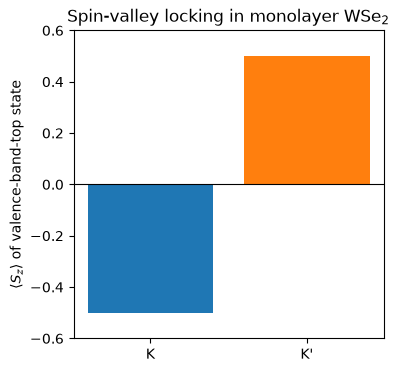

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["K", "K'"], [sz_k, sz_kprime], color=["tab:blue", "tab:orange"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(-0.6, 0.6)
ax.set_ylabel(r"$\langle S_z\rangle$ of valence-band-top state")
ax.set_title("Spin-valley locking in monolayer WSe$_2$")
plt.show()